<a href="https://colab.research.google.com/github/jjmoncus/MV_coursework_2/blob/main/Machine_Vision_Final_Lab_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Need to somehow figure out how to get the right python version on colab

In [36]:
import sys
print(sys.version)

3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]


# Load Dependencies

In [37]:
!pip install boto3 -q
!pip install opencv-python torch numpy torchvision
!pip install seaborn
!pip install huggingface_hub


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau


import copy
import os
import cv2
import numpy as np
import shutil
import random
import psutil

from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Find and apply device

In [39]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


# Download the data

In [40]:
# import boto3
# from botocore import UNSIGNED
# from botocore.config import Config
# import os

# # Connect to S3 without authentication (public bucket)
# s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# bucket_name = 'prism-mvta'
# prefix = 'training-and-validation-data/'
# download_dir = './video-data'

# # refresh `download_dir` if already exists
# if os.path.exists(download_dir):
#     shutil.rmtree(download_dir)
#     print(f"Removed {download_dir}")
# else:
#     print(f"{download_dir} not found - making now.")
# os.makedirs(download_dir, exist_ok=True)

# # List all objects in the S3 path
# paginator = s3.get_paginator('list_objects_v2')
# pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

# video_names = []

# for page in pages:
#     if 'Contents' not in page:
#         print("No files found at the specified path! Go and complain to the TAs!")
#         break

#     for obj in page['Contents']:
#         key = obj['Key']
#         filename = os.path.basename(key)

#         if not filename:
#             continue

#         video_names.append(filename)

#         local_path = os.path.join(download_dir, filename)
#         print(f"Downloading: {filename}")
#         s3.download_file(bucket_name, key, local_path)

# print("\n" + "="*50)
# print("Downloaded videos:")
# print("="*50)
# for name in video_names:
#     print(name)

# print(f"\nTotal: {len(video_names)} files")

# Create your Datasets and Dataloaders

 - stride temporally by 10, so for a video of max 1000 frames, we only ever load 100 frames into memory.

 - after loading strided frames, pad all videos to 100 frames by repeating the final frame until each video is 100 frames long.

    - instead of padding with blank frames of black, we pad so that it appears that the person is holding still in their final position.

In [41]:
# Here is a basic implementation of the above two TODOs. You can assume the first TODO is completed correctly.
# Please modify this code to suit you best, as you decide on your preferred model architecture.
# For example, below here we are padding every video to 1,000 frames. That may or may not be a good idea.


class VideoDataset(Dataset):
    """Dataset for loading videos from a folder. Labels from filename prefix."""

    def __init__(self, video_dir, frame_size=(224, 224), transform=None):
        self.video_dir = video_dir
        self.frame_size = frame_size
        self.transform = transform

        self.video_files = [
            f for f in os.listdir(video_dir)
            if f.endswith(('.mp4', '.avi', '.mov'))
        ]

        self.labels = [
            int(f.split('_')[0]) for f in self.video_files
        ]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = os.path.join(self.video_dir, self.video_files[idx])
        frames = self._load_video(video_path)
        label = self.labels[idx]

        if self.transform:
            frames = self.transform(frames)

        return frames, label

    def _load_video(self, path, stride = 10, max_frames = 100):
        cap = cv2.VideoCapture(path)
        frames = []
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # only add every `stride`'th frame
            if frame_count % stride == 0:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.frame_size[1], self.frame_size[0]))
                frames.append(frame)

            frame_count +=1

            if len(frames) == max_frames:
                break

        cap.release()

        frames = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float() / 255

        return frames


def collate_fn(batch):
    frames_list, labels = zip(*batch)
    target_frames = 100  # Updated to your requested 200

    padded_frames = []
    for frames in frames_list:
        # frames shape: (Channels, Time, Height, Width)
        num_frames = frames.shape[1]
        
        if num_frames < target_frames:
            # 1. Grab the last frame: (C, 1, H, W)
            last_frame = frames[:, -1:, :, :]
            
            # 2. Calculate how many times to repeat it
            padding_size = target_frames - num_frames
            
            # 3. Create the padding by repeating the last frame
            padding = last_frame.repeat(1, padding_size, 1, 1)
            
            # 4. Concatenate along the temporal dimension (dim=1)
            frames = torch.cat([frames, padding], dim=1)
            
        elif num_frames > target_frames:
            # Truncate if the video is too long
            frames = frames[:, :target_frames, :, :]
            
        padded_frames.append(frames)

    # Combine list into a single batch tensor: (Batch, C, T, H, W)
    frames_batch = torch.stack(padded_frames, dim=0)
    labels_batch = torch.tensor(labels)

    return frames_batch, labels_batch


def get_dataloaders(video_dir, batch_size=5, val_split=0.2, collate_fn = None):
    """Create train and validation dataloaders."""

    full_dataset = VideoDataset(video_dir)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"Train: {len(train_dataset)} videos, Val: {len(val_dataset)} videos\n")

    return train_loader, val_loader

In [42]:
train_loader, val_loader = get_dataloaders("./video-data", collate_fn = collate_fn)
frames, labels = next(iter(train_loader))
print(frames.shape)
print(labels)

Train: 62 videos, Val: 15 videos

torch.Size([5, 3, 100, 224, 224])
tensor([2, 4, 3, 3, 2])


# Model

In [59]:
import torch
import torch.nn as nn
from torchvision import models

class VideoResNetModel(nn.Module):
    def __init__(self, use_pretrained=True):
        super().__init__()
        
        # 1. Load Pre-trained ResNet18
        # weights=models.ResNet18_Weights.DEFAULT is the modern way to load pre-trained
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        
        # 2. Extract the feature extractor (all layers except the final fc layer)
        # ResNet18's final layer before the classifier is an Global Average Pool
        # which outputs 512 features.
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.backbone.parameters():
            param.requires_grad = False  # Gradients are no longer calculated/stored

        # 4. Temporal Processor
        # ResNet18 (after Global Average Pool) outputs 512 features per frame.
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(512, 128, kernel_size=3, stride=2, padding=1), # 100 -> 50
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 50 -> 25
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 25 -> 13
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1)
        )
        
        # 5. Classifier
        # Output of temporal is [B, 32, 13]. Flattened = 32 * 13 = 416
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(416, 1) 
        )

    def forward(self, x):
        # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        
        # Reshape for Spatial: [B*T, C, H, W]
        x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
        # Pass through ResNet backbone
        # Output is [B*T, 512, 1, 1]
        spatial_features = self.backbone(x_in) 
        
        # Reshape for Temporal: [B, 512, T]
        temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
        # Temporal Conv
        temporal_out = self.temporal_conv(temporal_in)
        
        # Classify
        return self.classifier(temporal_out)

# Specify Training Rules

In [55]:
def get_model_weight_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.requires_grad:
            # L2 Norm: square the values, sum them, and take the square root
            param_norm = p.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def get_memory_footprint():
    """Returns the current System RAM and GPU VRAM usage."""
    
    # System RAM
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / ( 1024**3 )
    
    # GPU VRAM usage (only if on "cuda")
    vram_gb = 0.0
    if torch.cuda.is_available():
        # memory_allocated is the actual tensor storage
        # memory_reserved includes the cache held by PyTorch
        vram_gb = torch.cuda.memory_reserved() / (1024**3)
    elif torch.backends.mps.is_available():
        # Using driver_allocated because it reflects the actual 
        # hardware pressure on the Unified Memory pool.
        vram_gb = torch.mps.driver_allocated_memory() / (1024**3)
        
    return ram_gb, vram_gb

def train_epoch(model, train_loader, optimizer, criterion, device, print_outputs = False):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # For each batch...
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # ... send data to the right device, 
        data, target = data.to(device), target.to(device)

        # ... correct target class labels (class outputs index starting at 0, the labels index at 1, so we subtract 1 from targets to match),
        # target = target.long() - 1 
        
        # ... zero gradients,
        optimizer.zero_grad()

        # ... send data through the model
        outputs = model(data)
        outputs = torch.flatten(outputs)
        preds = torch.round(outputs).int()

        # ... print mean and std of predictions if you want (helpful to see if the model is predicting the same output every time, i.e. a vanishing gradients problem).
        # if print_outputs:
        #     print(f"Output Mean: {outputs.mean().item():.4f}, Std: {outputs.std().item():.4f}")

        # ... calc loss,
        loss = criterion( outputs.float() , target.float() )

        # ... backward pass,
        loss.backward()

        # ... update optimizer,
        optimizer.step()

        # ... predict the most likely class,
        # _, preds = torch.max(outputs, 1)
        
        # ...update measurements, 
        total_loss += loss.item()
        correct += (preds == target).sum().item()
        total += target.size(0)
        print(f"Loss on batch {batch_idx}: {loss.item():.4f}")

    return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion, device, print_predictions = True):
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    running_preds = []

    with torch.no_grad():
        
        # for each batch...
        for data, target in test_loader:
            
            # ... send to the right device,
            data, target = data.to(device), target.to(device)

            # ... fix targets to align with model outputs,
            # target = target.long() - 1

            # ... send data through the model,
            outputs = model(data)
            outputs = torch.flatten(outputs)
            preds = torch.round(outputs)


            # ... calculate and update loss,
            total_loss += criterion( outputs.float() , target.float() ).item()

            # ... predict most likely class, 
            # _, preds = torch.max(outputs, 1)
            
            # ... and tally accuracy.
            correct += (preds == target).sum().item()
            total += target.size(0)
            if print_predictions:
                print(f"Sample Preds: {preds[:5].cpu().numpy() + 1}")
            running_preds.append(preds)
    
    flattened_running_preds = [item for sublist in running_preds for item in sublist]
    preds_sd = torch.std(torch.tensor(flattened_running_preds))

    return total_loss / len(test_loader), correct / total, preds_sd


# weight_decay = 0, 
def train_model(model, epochs = 10, lr = 1e-4, best_val_loss = float('inf'), start_epoch = 1):
    """Train and return your model."""

    # set optimizer and loss criterion 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # criterion = nn.CrossEntropyLoss()
    criterion = nn.MSELoss()

    # initialize LR scheduler (learning rate will drop to 50% the current rate after 3 epochs of no improvement)
    # scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    # dataloaders
    train_loader, val_loader = get_dataloaders(
        './video-data', 
        batch_size = 5, 
        val_split = 0.2,
        collate_fn = collate_fn
        )
    print("Got dataloaders.\n")
    print("Go time. Let the training commence.\n")

    # Initialize metrics to track
    train_losses, train_acces = [], []
    val_losses, val_acces = [], []

    # For each epoch...
    for epoch in range(start_epoch, start_epoch + epochs + 1):

        # ... grab the current learning rate, 
        # current_lr = optimizer.param_groups[0]["lr"]

        # ... train and validate, 
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, preds_sd = evaluate(model, val_loader, criterion, device)

        # ... step the learning rate scheduler
        # scheduler.step(val_loss)

        # ... and message if learning rate changed for the next epoch
        # new_lr = optimizer.param_groups[0]['lr']
        # if new_lr < current_lr:
        #     print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        # if new_lr < 1e-8:
        #     print(f"\n[EARLY STOPPING] LR {new_lr:.1e} is below threshold 1e-8. Training halted.")
        #     break

        # ... save evaluations,
        train_losses.append(train_loss)
        train_acces.append(train_acc)
        val_losses.append(val_loss)
        val_acces.append(val_acc)

        # ... track model metrics,
        ram, vram = get_memory_footprint()
        current_norm = get_model_weight_norm(model)

        print(f"Epoch {epoch}/{start_epoch + epochs - 1} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f} | "
              f"St.Dev. of Predictions: {preds_sd} | "
              f"RAM: {ram:.2f}GB | VRAM: {vram:.2f}GB | Weight Norm: {current_norm:.3f}")
        
        # # ... and, if this is the best model so far, save it.
        # if val_loss < best_val_loss:
        #     best_val_loss = val_loss
            
        #     checkpoint = {
        #         'epoch': epoch,
        #         'model_state_dict': model.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'scheduler_state_dict': scheduler.state_dict(),
        #         'best_val_loss': best_val_loss,
        #     }
            
        #     torch.save(checkpoint, 'best_video_model.pth', _use_new_zipfile_serialization = False)
        #     print(f"--- Epoch {epoch}: New best model saved! ---")

    return model, train_losses, train_acces, val_losses, val_acces

# Train and report training outcomes

Some functions to help with reporting losses and accuracies

In [57]:
def eval_plots(loss, acc, loss_title = "Running loss, per epoch", acc_title = "Running accuracy, per epoch"):

    fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(8, 4))

    # Plot data on the first axis (left plot)
    ax1.plot(loss)
    ax1.set_title(loss_title)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # Plot data on the second axis (right plot)
    ax2.plot(acc)
    ax2.set_title(acc_title)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")

    # Automatically adjust subplot parameters for a tight layout
    plt.tight_layout()

    # Display
    plt.show()

def report_training_results(train_losses, train_acces, val_losses, val_acces):

    eval_plots(
        train_losses, 
        train_acces, 
        "Running training loss, per epoch", 
        "Running training accuracy, per epoch" 
        )
    eval_plots(
        val_losses, 
        val_acces, 
        "Running evaluation loss, per epoch", 
        "Running evaluation accuracy, per epoch"
        )


# Actual training

In [60]:
# setting a manual seed for reproducibility
torch.manual_seed(0)
print(f"Using device: {device}\n")
model = VideoResNetModel().to(device)
model, train_losses, train_acces, val_losses, val_acces = train_model(model, epochs = 10, lr = 1e-3)

Using device: mps

Train: 62 videos, Val: 15 videos

Got dataloaders.

Go time. Let the training commence.

Loss on batch 0: 8.2861
Loss on batch 1: 5.7806
Loss on batch 2: 4.8183
Loss on batch 3: 3.5487
Loss on batch 4: 5.2154
Loss on batch 5: 2.1011
Loss on batch 6: 5.2455
Loss on batch 7: 0.2438
Loss on batch 8: 1.6478
Loss on batch 9: 3.7535
Loss on batch 10: 0.7973
Loss on batch 11: 1.2728
Loss on batch 12: 0.1551
Sample Preds: [3. 2. 2. 2. 3.]
Sample Preds: [3. 2. 2. 2. 4.]
Sample Preds: [3. 3. 3. 2. 3.]
Epoch 1/10 | Train Loss: 3.2974, Train Acc: 0.24 | Val Loss: 4.8617, Val Acc: 0.13 | St.Dev. of Predictions: 0.6324555277824402 | RAM: 0.11GB | VRAM: 12.68GB | Weight Norm: 17.425
Loss on batch 0: 0.8922
Loss on batch 1: 0.5082
Loss on batch 2: 0.6585
Loss on batch 3: 0.6178
Loss on batch 4: 0.8038
Loss on batch 5: 0.7554
Loss on batch 6: 0.6687
Loss on batch 7: 1.3017
Loss on batch 8: 1.4758
Loss on batch 9: 0.9758
Loss on batch 10: 0.3962
Loss on batch 11: 0.5377
Loss on batch 

Report outcomes for this training cycle

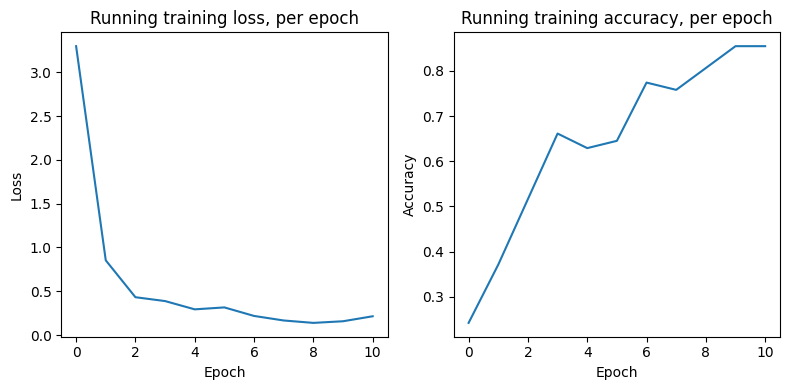

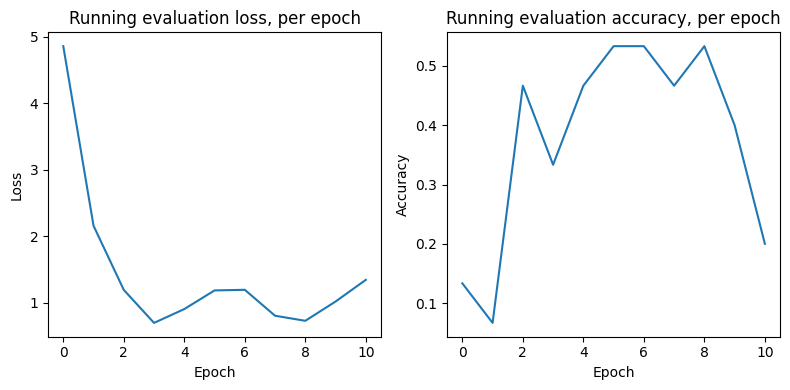

In [62]:
report_training_results(train_losses, train_acces, val_losses, val_acces)

# Full final evaluation of best model on training data

Functions to help with evaluation

In [69]:
# More comprehensive model evaluation (no transformations)
def full_evaluate(model, test_loader, dataset, device):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_times = []

    print("\n")

    with torch.no_grad():
        # for each batch, ...
        for idx, (frames, labels) in enumerate(test_loader):
            
            # ... grab the frames and labels,
            frames, labels = frames.to(device), labels.to(device)

            # ... time the forward pass,
            start_time = time.time()
            outputs = model(frames)
            if device.type == 'cuda':
                torch.cuda.synchronize()  # wait for GPU to finish
            elif device.type == "mps":
                torch.mps.synchronize()  # wait for GPU to finish
            end_time = time.time()
            inference_time = (end_time - start_time) * 1000  # ms
            all_times.append(inference_time)

            # ... make predictions
            # _, preds = torch.max(outputs, 1)
            # preds = preds + 1
            outputs = torch.flatten(outputs)
            preds = torch.round(outputs)
            

            # ... evalute if we're correct or not
            for i in range(labels.size(0)):
                batch_idx = idx * test_loader.batch_size + i
                video_name = dataset.video_files[batch_idx]
                pred = preds[i].item()
                true_label = labels[i].item()
                is_correct = "✓" if pred == true_label else "✗"
                print(f"{is_correct}  pred={pred}  true={true_label}  |  {video_name}")

            # ... tally our results
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Now, generate a confusion matrix of all our incorrect predictions, ...
    unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plot_confusion_matrix(cm, unique_labels)

    # ... and tally our final accuracy
    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_times

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted count')
    plt.ylabel('Actual count')
    plt.title('Confusion Matrix: Number of Push-ups')
    plt.show()
    
def run_inference(model, bucket_name='training-and-validation-data', dataset_loc = "./pose-data"):

    model = model.to(device)

    # Create dataloader
    val_dataset = VideoDataset(dataset_loc)
    test_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"\nRunning inference on {len(val_dataset)} test videos...")

    # Warmup
    # if device.type == 'cuda' or device.type == "mps":
    #     # dummy = torch.randn(1, 3, 100, 224, 224).to(device)
    #     dummy = torch.randn(1, 100, 33, 4).to(device)
    #     with torch.no_grad():
    #         _ = model(dummy)
    #     if device.type == 'cuda':
    #         torch.cuda.synchronize()  # wait for GPU to finish
    #     elif device.type == "mps":
    #         torch.mps.synchronize()  # wait for GPU to finish

    total_start = time.time()
    accuracy, preds, labels, times = full_evaluate(model, test_loader, val_dataset, device)
    total_end = time.time()

    # Summary
    num_correct = sum(p == l for p, l in zip(preds, labels))
    num_wrong = len(preds) - num_correct

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Total videos:         {len(preds)}")
    print(f"Correct:              {num_correct}")
    print(f"Incorrect:                {num_wrong}")
    print(f"")
    print(f"ACCURACY:             {accuracy*100:.2f}%")
    print(f"")
    print(f"Total time:           {total_end - total_start:.2f}s")
    print(f"Avg per video:        {sum(times) / len(times):.1f}ms")
    print(f"Min latency:          {min(times):.1f}ms")
    print(f"Max latency:          {max(times):.1f}ms")
    print("="*50)
    return accuracy, preds, labels


Load the best model from training, saved as a checkpoint, and run inference

In [68]:
model

VideoResNetModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s


Running inference on 77 test videos...


✓  pred=2.0  true=2  |  2_sadfasjldkfjaseifj.mp4
✓  pred=2.0  true=2  |  2_sdafkjaslkclaksdjkas.mp4
✓  pred=4.0  true=4  |  4_kling_20251206_Text_to_Video_Generate_a_28_0.mp4
✗  pred=2.0  true=3  |  3_kling_dskfseu.mp4
✗  pred=3.0  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_190_0.mp4
✓  pred=3.0  true=3  |  3_kling_kdjflaskdjf.mp4
✓  pred=2.0  true=2  |  2_dsalkfjalwkenlke.mp4
✓  pred=3.0  true=3  |  3_dsjlaeijlksjdfie.mp4
✓  pred=3.0  true=3  |  3_kling_20251205_Text_to_Video_On_a_playg_5028_0.mp4
✓  pred=4.0  true=4  |  4_sadlfkjlknewkjejk.mp4
✗  pred=2.0  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_2.mp4
✓  pred=4.0  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_561_1.mp4
✗  pred=1.0  true=2  |  2_difficult_2.mp4
✗  pred=4.0  true=3  |  3_sdlkjslndflkseijlkjef.mp4
✓  pred=3.0  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_0.mp4
✓  pred=6.0  true=6  |  6_dfjewaijsldkjfsaef.mp4
✓  pred=4.0  true=4  |  4

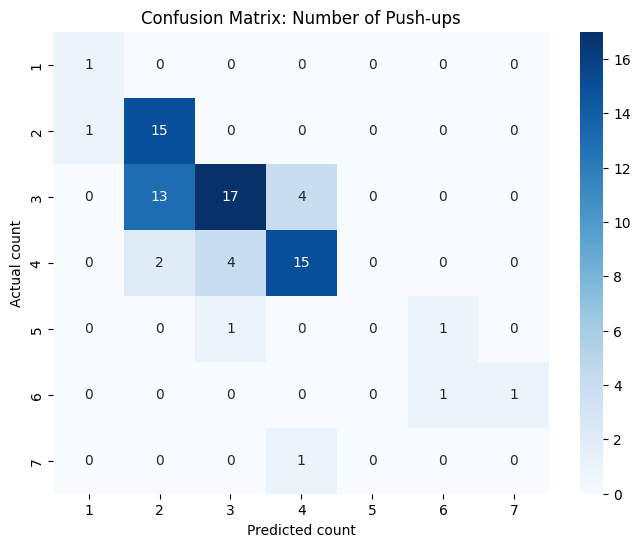


SUMMARY
Total videos:         77
Correct:              49
Incorrect:                28

ACCURACY:             63.64%

Total time:           64.68s
Avg per video:        174.8ms
Min latency:          147.6ms
Max latency:          1309.6ms


In [70]:
# model = PoseModel()
# checkpoint = torch.load('best_video_model.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# print(f"Successfully loaded model from epoch {checkpoint['epoch']}")
# model.eval()
# model.to(device)
_, _, _ = run_inference(model, dataset_loc = "./video-data")